# sim3 visualization

This notebook reads the aggregated `sim3` output and makes a few simple plots to show how alignment behavior changes as mutation error increases.

## What this notebook plots

- error rate vs percent identity
- error rate vs bit score
- error rate vs gaps
- an optional scatter plot of bit score vs percent identity

It also saves the figures into a `plots/` directory next to the metrics table.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import pandas as pd
from pathlib import Path

metrics_path = Path("../results/sim3/test/seed42/metrics_all.tsv")
print(metrics_path.resolve())
print(metrics_path.exists())

df = pd.read_csv(metrics_path, sep="\t")
df.head()

/home/ha-ibnu/Code/pairwise_sim/results/sim3/test/seed42/metrics_all.tsv
True


,seq_id,error_rate,seed,len_ref,len_query,n_sub,n_ins,n_del,bitscore,evalue,align_len,pct_ident,gaps,run_dir
0,test,0.0,42,2277,2277,0,0,0,4107.0,0.0,2277,100.0,0,results/sim3/test/seed42/e000
1,test,1.0,42,2277,2278,16,4,3,3985.0,0.0,2281,99.0,7,results/sim3/test/seed42/e001
2,test,2.0,42,2277,2277,32,7,7,3862.0,0.0,2284,98.0,14,results/sim3/test/seed42/e002
3,test,3.0,42,2277,2277,48,10,10,3752.0,0.0,2286,97.0,18,results/sim3/test/seed42/e003
4,test,4.0,42,2277,2276,64,13,14,3638.0,0.0,2287,96.0,25,results/sim3/test/seed42/e004


In [9]:
# Update this path if you run a different experiment.
metrics_path = Path('../results/sim3/test/seed42/metrics_all.tsv')

if not metrics_path.exists():
    raise FileNotFoundError(f'Metrics file not found: {metrics_path.resolve()}')

plots_dir = metrics_path.parent / 'plots'
plots_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(metrics_path, sep='\t')
df = df.sort_values('error_rate').reset_index(drop=True)
df.head()

,seq_id,error_rate,seed,len_ref,len_query,n_sub,n_ins,n_del,bitscore,evalue,align_len,pct_ident,gaps,run_dir
0,test,0.0,42,2277,2277,0,0,0,4107.0,0.0,2277,100.0,0,results/sim3/test/seed42/e000
1,test,1.0,42,2277,2278,16,4,3,3985.0,0.0,2281,99.0,7,results/sim3/test/seed42/e001
2,test,2.0,42,2277,2277,32,7,7,3862.0,0.0,2284,98.0,14,results/sim3/test/seed42/e002
3,test,3.0,42,2277,2277,48,10,10,3752.0,0.0,2286,97.0,18,results/sim3/test/seed42/e003
4,test,4.0,42,2277,2276,64,13,14,3638.0,0.0,2287,96.0,25,results/sim3/test/seed42/e004


In [10]:
df[['error_rate', 'pct_ident', 'bitscore', 'gaps', 'len_ref', 'len_query']].describe()

,error_rate,pct_ident,bitscore,gaps,len_ref,len_query
count,31.000000,31.000000,31.000000,31.000000,31.0,31.000000
mean,15.000000,85.870968,2448.064516,80.258065,2277.0,2277.000000
std,9.092121,8.257287,964.499488,44.737730,0.0,0.516398
min,0.000000,73.000000,933.000000,0.000000,2277.0,2276.000000
25%,7.500000,78.500000,1625.500000,46.000000,2277.0,2277.000000
50%,15.000000,86.000000,2431.000000,81.000000,2277.0,2277.000000
75%,22.500000,92.500000,3239.000000,119.500000,2277.0,2277.000000
max,30.000000,100.000000,4107.000000,153.000000,2277.0,2278.000000


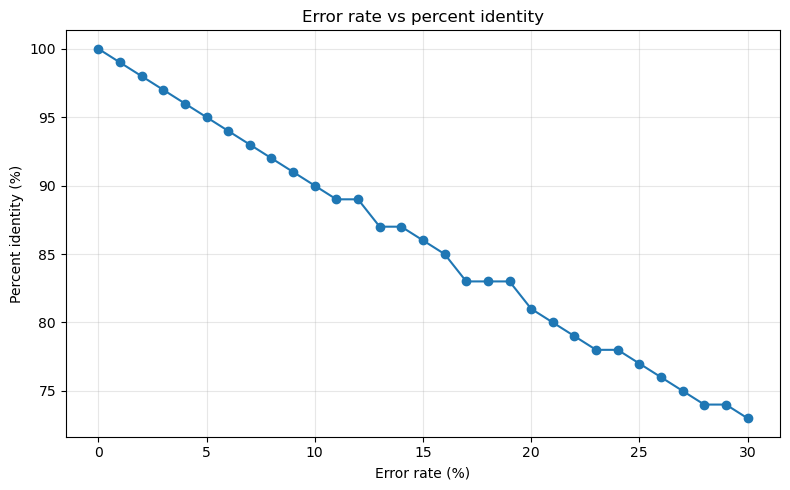

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(df['error_rate'], df['pct_ident'], marker='o')
plt.xlabel('Error rate (%)')
plt.ylabel('Percent identity (%)')
plt.title('Error rate vs percent identity')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(plots_dir / 'error_vs_pct_identity.png', dpi=300, bbox_inches='tight')
plt.show()

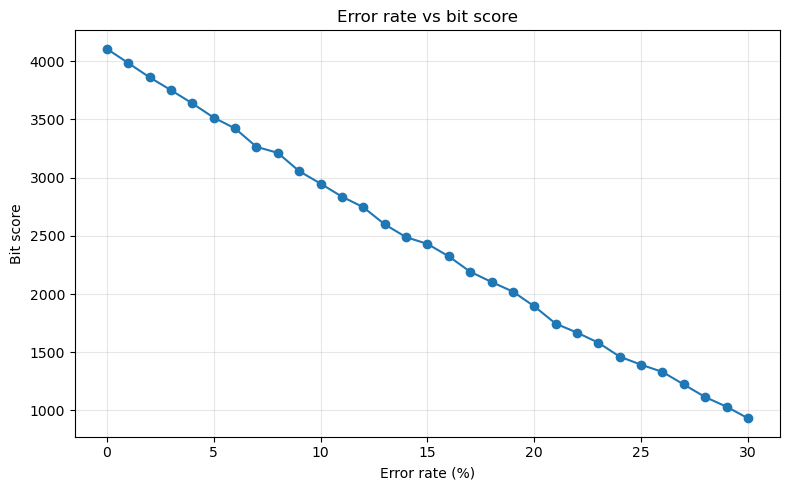

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(df['error_rate'], df['bitscore'], marker='o')
plt.xlabel('Error rate (%)')
plt.ylabel('Bit score')
plt.title('Error rate vs bit score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(plots_dir / 'error_vs_bitscore.png', dpi=300, bbox_inches='tight')
plt.show()

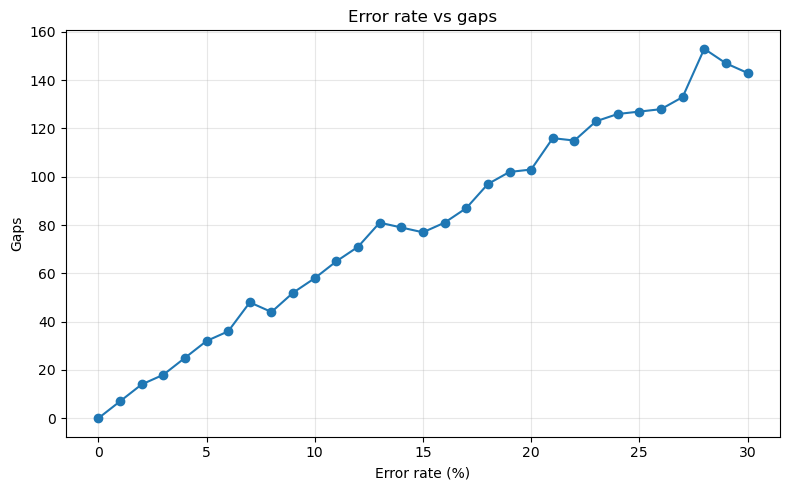

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(df['error_rate'], df['gaps'], marker='o')
plt.xlabel('Error rate (%)')
plt.ylabel('Gaps')
plt.title('Error rate vs gaps')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(plots_dir / 'error_vs_gaps.png', dpi=300, bbox_inches='tight')
plt.show()

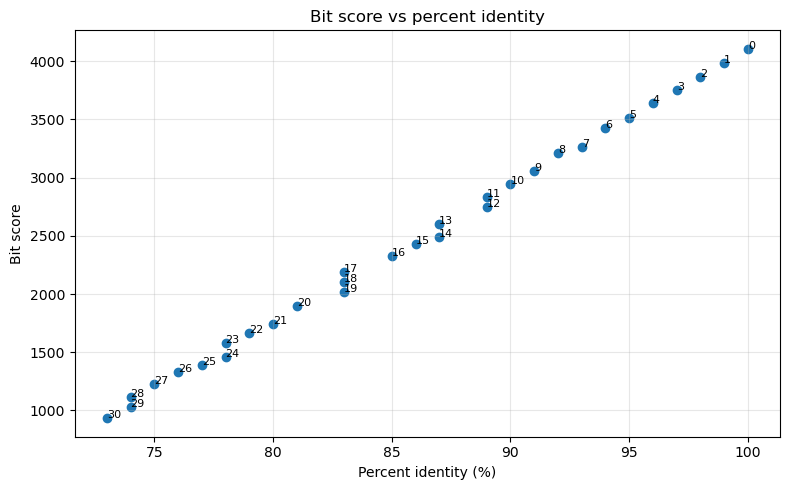

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(df['pct_ident'], df['bitscore'])
for _, row in df.iterrows():
    plt.annotate(int(round(row['error_rate'])), (row['pct_ident'], row['bitscore']), fontsize=8)
plt.xlabel('Percent identity (%)')
plt.ylabel('Bit score')
plt.title('Bit score vs percent identity')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(plots_dir / 'bitscore_vs_pct_identity.png', dpi=300, bbox_inches='tight')
plt.show()

## Interpretation notes

Expected behavior:

- percent identity should generally decrease as error rate increases
- bit score should generally decrease
- gaps should generally increase, though not always perfectly monotonically because BLAST optimizes a local gapped alignment
- query length may fluctuate slightly because insertions and deletions can balance or differ by a few events after rounding
